# BDG2 Profiler — Paper 3 (federated load forecasting)

Profiles the BDG2 electricity meters, joins metadata + weather, reports coverage/missingness per building, and shortlists a clean subset of buildings to use as **federated clients**.

**Expected data location:** `MyDrive/paper3_fed_load/data/`
- `data/meters/cleaned/electricity_cleaned.csv`
- `data/weather/weather.csv`
- `data/metadata/metadata.csv`

**Outputs:** written to `MyDrive/paper3_fed_load/bdg2_profile_out/`

Run the cells top to bottom.

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Imports and paths

In [8]:
import os, sys
import numpy as np
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/paper3_fed_load"
DATA_DIR    = os.path.join(PROJECT_DIR, "data")
OUT_DIR     = os.path.join(PROJECT_DIR, "bdg2_profile_out")
os.makedirs(OUT_DIR, exist_ok=True)
print("project:", PROJECT_DIR)

project: /content/drive/MyDrive/Colab Notebooks/paper3_fed_load


## 3. Config — edit to change the federated-client filter

In [9]:
TARGET_METER = "electricity"
USE_CLEANED  = True
MIN_COVERAGE = 0.90                    # min fraction of the 2-yr timeline present
KEEP_USES    = ["Office", "Education"] # None = keep all uses
MAX_CLIENTS  = 60                      # None = no cap

## 4. Helper functions

In [10]:
def find_col(df, cands):
    lut = {c.lower(): c for c in df.columns}
    for c in cands:
        if c.lower() in lut:
            return lut[c.lower()]
    return None


def load_inputs():
    sub = "cleaned" if USE_CLEANED else "raw"
    suf = "_cleaned" if USE_CLEANED else ""
    mp = os.path.join(DATA_DIR, "meters", sub, f"{TARGET_METER}{suf}.csv")
    wp = os.path.join(DATA_DIR, "weather", "weather.csv")
    dp = os.path.join(DATA_DIR, "metadata", "metadata.csv")
    for p in (mp, wp, dp):
        if not os.path.exists(p):
            sys.exit(f"[ERROR] missing file: {p}\n        Check your folder structure under {DATA_DIR}")
        if os.path.getsize(p) < 2000 and "git-lfs" in open(p).read(200):
            sys.exit(f"[ERROR] {p} is a Git-LFS POINTER, not real data.\n"
                     f"        Download the real CSVs from Zenodo (https://doi.org/10.5281/zenodo.3887306) or run `git lfs pull`.")
    print(f"[load] meters   : {mp}")
    meters = pd.read_csv(mp)
    print(f"[load] weather  : {wp}")
    weather = pd.read_csv(wp)
    print(f"[load] metadata : {dp}")
    meta = pd.read_csv(dp)
    return meters, weather, meta


def profile_buildings(meters):
    ts = find_col(meters, ["timestamp", "time", "datetime"])
    meters[ts] = pd.to_datetime(meters[ts])
    meters = meters.sort_values(ts).reset_index(drop=True)
    bcols = [c for c in meters.columns if c != ts]
    n = len(meters)
    print(f"[info] {n} hourly timestamps, {len(bcols)} metered buildings")
    rows = []
    for b in bcols:
        s = meters[b]; v = s.dropna(); nobs = int(s.notna().sum())
        rows.append(dict(
            building_id=b, n_obs=nobs, coverage=round(nobs / n, 4),
            pct_missing=round(100 * (1 - nobs / n), 2),
            mean_load=round(float(v.mean()), 2) if len(v) else np.nan,
            std_load=round(float(v.std()), 2) if len(v) else np.nan,
            min_load=round(float(v.min()), 2) if len(v) else np.nan,
            max_load=round(float(v.max()), 2) if len(v) else np.nan,
            n_zeros=int((v == 0).sum())))
    return pd.DataFrame(rows)


def join_metadata(prof, meta):
    bid = find_col(meta, ["building_id", "building"])
    use = find_col(meta, ["primaryspaceusage", "primary_use"])
    site = find_col(meta, ["site_id", "site"])
    sqm = find_col(meta, ["sqm", "square_meters"])
    tz = find_col(meta, ["timezone", "time_zone"])
    keep = [c for c in [bid, use, site, sqm, tz] if c]
    m = meta[keep].rename(columns={bid: "building_id", use: "primary_use",
                                   site: "site_id", sqm: "sqm", tz: "timezone"})
    return prof.merge(m, on="building_id", how="left")


def weather_coverage(weather):
    site = find_col(weather, ["site_id", "site"])
    tcol = find_col(weather, ["airTemperature", "temperature"])
    if site is None:
        return None
    cov = weather.groupby(site)[tcol].apply(lambda s: s.notna().mean()) if tcol else None
    out = pd.DataFrame({"site_id": weather[site].unique()})
    if cov is not None:
        out = out.merge(cov.rename("site_airtemp_coverage").reset_index()
                        .rename(columns={site: "site_id"}), on="site_id", how="left")
    return out

## 5. Run the profile

In [12]:
meters, weather, meta = load_inputs()
prof = profile_buildings(meters)
prof = join_metadata(prof, meta)
wc = weather_coverage(weather)
if wc is not None:
    prof = prof.merge(wc, on="site_id", how="left")

prof = prof.sort_values("coverage", ascending=False)
prof.to_csv(os.path.join(OUT_DIR, "building_profile.csv"), index=False)

if "primary_use" in prof:
    (prof.groupby("primary_use")
        .agg(n_buildings=("building_id", "count"),
             mean_coverage=("coverage", "mean"),
             mean_load=("mean_load", "mean"))
        .sort_values("n_buildings", ascending=False).round(3)
        .to_csv(os.path.join(OUT_DIR, "summary_by_use.csv")))
if "site_id" in prof:
    (prof.groupby("site_id")
        .agg(n_buildings=("building_id", "count"),
             mean_coverage=("coverage", "mean"))
        .sort_values("n_buildings", ascending=False).round(3)
        .to_csv(os.path.join(OUT_DIR, "summary_by_site.csv")))
print("profiled", len(prof), "buildings")

[load] meters   : /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/data/meters/cleaned/electricity_cleaned.csv
[load] weather  : /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/data/weather/weather.csv
[load] metadata : /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/data/metadata/metadata.csv
[info] 17544 hourly timestamps, 1578 metered buildings
profiled 1578 buildings


## 6. Shortlist federated clients

In [13]:
cand = prof[prof["coverage"] >= MIN_COVERAGE].copy()
if KEEP_USES and "primary_use" in cand:
    cand = cand[cand["primary_use"].isin(KEEP_USES)]
if "site_airtemp_coverage" in cand:
    cand = cand[cand["site_airtemp_coverage"].fillna(0) >= 0.5]
cand = cand.sort_values("coverage", ascending=False)
if MAX_CLIENTS:
    cand = cand.head(MAX_CLIENTS)
cand.to_csv(os.path.join(OUT_DIR, "candidate_clients.csv"), index=False)
print("shortlisted", len(cand), "clients ->", os.path.join(OUT_DIR, "candidate_clients.csv"))

shortlisted 60 clients -> /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/bdg2_profile_out/candidate_clients.csv


## 7. Summary report

In [14]:
print("=" * 60)
print("BDG2 PROFILE SUMMARY")
print("=" * 60)
print(f"metered buildings (electricity) : {len(prof)}")
print(f"median coverage                 : {prof['coverage'].median():.3f}")
print(f"buildings >= {MIN_COVERAGE:.0%} coverage        : {(prof['coverage'] >= MIN_COVERAGE).sum()}")
if "primary_use" in prof:
    print("\nby primary use (top 10):")
    print(prof["primary_use"].value_counts().head(10).to_string())
print(f"\nSHORTLISTED FEDERATED CLIENTS   : {len(cand)}")
print(f"  filter: use in {KEEP_USES}, coverage >= {MIN_COVERAGE:.0%}, cap {MAX_CLIENTS}")
print(f"\nwrote outputs to: {OUT_DIR}")

BDG2 PROFILE SUMMARY
metered buildings (electricity) : 1578
median coverage                 : 0.986
buildings >= 90% coverage        : 1440

by primary use (top 10):
primary_use
Education                        604
Office                           296
Entertainment/public assembly    203
Public services                  166
Lodging/residential              149
Healthcare                        27
Other                             26
Parking                           23
Warehouse/storage                 14
Manufacturing/industrial          11

SHORTLISTED FEDERATED CLIENTS   : 60
  filter: use in ['Office', 'Education'], coverage >= 90%, cap 60

wrote outputs to: /content/drive/MyDrive/Colab Notebooks/paper3_fed_load/bdg2_profile_out


## 8. Quick figures

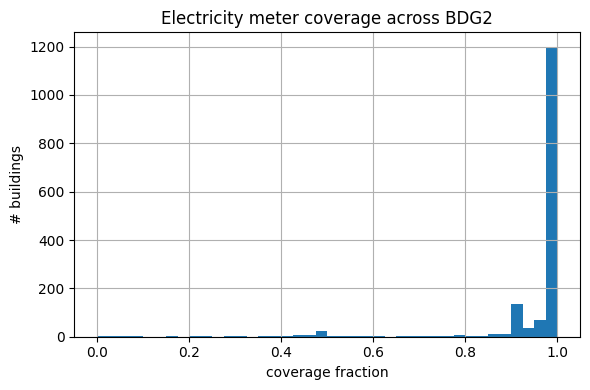

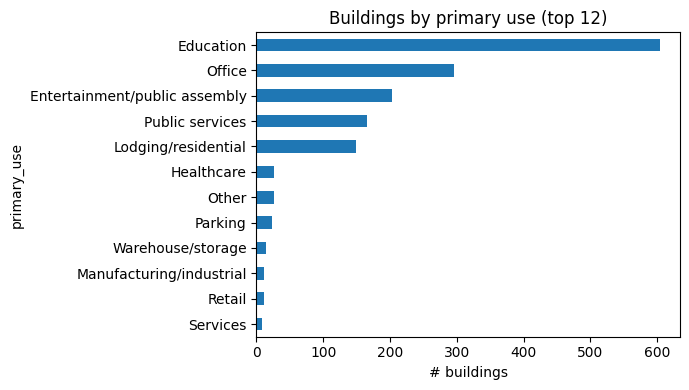

In [15]:
import matplotlib.pyplot as plt
fig_dir = os.path.join(OUT_DIR, "figures"); os.makedirs(fig_dir, exist_ok=True)

plt.figure(figsize=(6, 4)); prof["coverage"].hist(bins=40)
plt.xlabel("coverage fraction"); plt.ylabel("# buildings")
plt.title("Electricity meter coverage across BDG2"); plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "coverage_hist.png"), dpi=130); plt.show()

if "primary_use" in prof:
    plt.figure(figsize=(7, 4))
    prof["primary_use"].value_counts().head(12).plot.barh()
    plt.gca().invert_yaxis(); plt.xlabel("# buildings")
    plt.title("Buildings by primary use (top 12)"); plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, "by_use.png"), dpi=130); plt.show()

## 9. Preview the shortlist

In [16]:
cand.head(20)

,building_id,n_obs,coverage,pct_missing,mean_load,std_load,min_load,max_load,n_zeros,primary_use,site_id,sqm,timezone,site_airtemp_coverage
1265,Hog_education_Josh,17544,1.0,0.0,133.40,80.50,0.00,426.93,2395,Education,Hog,5630.5,US/Central,0.999886
155,Robin_education_Karyl,17544,1.0,0.0,62.13,46.79,0.01,195.38,0,Education,Robin,2992.0,Europe/London,0.999943
138,Robin_office_Victor,17544,1.0,0.0,53.40,20.07,8.03,117.29,0,Office,Robin,3724.0,Europe/London,0.999943
820,Lamb_education_Emilie,17544,1.0,0.0,4.60,4.80,0.00,22.50,1122,Education,Lamb,1303.0,Europe/London,0.999886
701,Lamb_education_Camille,17544,1.0,0.0,22.19,30.51,0.00,134.20,7240,Education,Lamb,6382.0,Europe/London,0.999886
1211,Hog_office_Alisha,17544,1.0,0.0,8.83,5.91,0.00,22.90,5003,Office,Hog,3103.1,US/Central,0.999886
1279,Hog_office_Bill,17544,1.0,0.0,290.85,95.28,85.28,595.90,0,Office,Hog,13375.5,US/Central,0.999886
1275,Hog_office_Gustavo,17544,1.0,0.0,531.27,357.85,19.34,1205.45,0,Office,Hog,6582.4,US/Central,0.999886
152,Robin_office_Zelma,17544,1.0,0.0,109.96,33.44,29.70,204.50,0,Office,Robin,7607.0,Europe/London,0.999943
1216,Hog_office_Merilyn,17544,1.0,0.0,30.20,8.70,9.09,59.50,0,Office,Hog,3446.3,US/Central,0.999886
